# Esercizio 1 - Circuito a 1 qubit con H e misura

- `measure_all()` dichiara i cbit necessari da solo, quindi si potrebbe mettere anche `qc=QuantumCircuit(1)`
- `qc.draw('mpl', style='iqp')` invece di `qc.draw('mpl')` per evitare futuri warning
    - FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)
- Perchè non basta `measure`? Perchè bisogna usare un silmulatore? 
    * il QuantumCircuit è una descrizione, non un'esecuzione. Una lista ordinata di istruzioni
    * è il backend che parte da uno stato e gli applica i vari gate seguendo le istruzioni del codice
- `BasicAer` comando che è stato tolto in Qiskit v1.0 -> sostituito con `BasicProvider`
    - "DeprecationWarning: BasicAer is deprecated since Qiskit 0.46 and will be removed in Qiskit 1.0. The BasicAer (qiskit.providers.basicaer) module has been superseded by  qiskit.providers.basic_provider, and all its classes have been renamed to follow a new naming convention. More information and migration guidelines can be found in the 0.46 API docs for BasicAer.
    - Fonte: https://quantum.cloud.ibm.com/docs/guides/qiskit-1.0-features


- RISULTATO: Esempio concettuale di output: `{'1': 527, '0': 473}`
    - significa che su 1000 shot totali, lo stato "0" è stato misurato 527 volte e lo stato "1" 473 volte

{'0': 510, '1': 490}


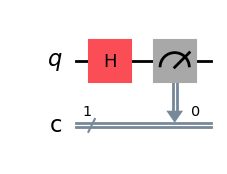

In [42]:

from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicProvider

qc=QuantumCircuit(1,1)
qc.h(0)
qc.measure(0,0)

backend = BasicProvider().get_backend("basic_simulator")
tqc = transpile(qc, backend)
job = backend.run(tqc, shots=1000)
counts = job.result().get_counts()
print(counts)

qc.draw('mpl', style='iqp')



- Dalla v1.0 i backend `statevector_simulator` e `unitary_simulator` usati nel libro sono stati rimossi perché duplicavano funzionalità già presenti in `qiskit.quantum_info`: si usano quindi direttamente `Statevector(qc)` e `Operator(qc)`.
    * Per vettore di stato e matrice unitaria non serve più il passaggio per il backend perché sono calcoli matematici deterministici, non esecuzioni
- IMPORTANTE: Statevector e Operator NON accetta circuiti che contengono misure. Operator non accetta nemmeno i reset
    * vettore di stato e matrice unitaria descrivono un'evoluzione unitaria, mentre la misura fa collassare lo stato
- RISULTATO: 
    1. Esempio concettuale di output: `Statevector([0.70710678+0.j, 0.70710678+0.j], dims=(2,))`
        - sono le due ampiezze di probabilità per gli stati |0⟩, |1⟩
        - il valore 0.7071 corrisponde circa a 1/√2, tipico di una sovrapposizione bilanciata, |0⟩ e |1⟩ hanno la stessa ampiezza 1/√2
        - è lo stato |+⟩ = (|0⟩ + |1⟩)/√2, ottenuto applicando H a |0⟩
    2. Esempio concettuale di output: `Operator([[ 0.70710678+0.j,  0.70710678+0.j], [ 0.70710678+0.j, -0.70710678+0.j]], input_dims=(2,), output_dims=(2,))`
        - l'output è una matrice quadrata di numeri complessi (una riga e una colonna per ogni stato di base)
        - è la matrice di Hadamard: 1/√2 · [[1, 1], [1, -1]]
        - ogni colonna è lo stato in uscita per uno stato di base in ingresso: prima colonna = H|0⟩ = |+⟩, seconda colonna = H|1⟩ = |−⟩
        - la prima colonna coincide con lo Statevector del punto 1, perché il circuito parte da |0⟩

In [43]:
from qiskit.quantum_info import Statevector, Operator

qc=QuantumCircuit(1,1)
qc.h(0)

statevector = Statevector(qc)
print(statevector)

unitary = Operator(qc)
print(unitary)

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
Operator([[ 0.70710678+0.j,  0.70710678+0.j],
          [ 0.70710678+0.j, -0.70710678+0.j]],
         input_dims=(2,), output_dims=(2,))


# Esercizio 2 - Stato di Bell: H + CX, verifica dei conteggi 00 e 11

- RISULTATO: Esempio concettuale di output: `{'00': 495, '11': 505}`
    - significa che su 1000 shot totali, lo stato "00" è stato misurato 495 volte e lo stato "11" 505 volte
    - questo risultato è tipico di un circuito che crea uno stato di Bell (sovrapposizione entangled tra i due esiti "00" e "11")

{'00': 493, '11': 507}


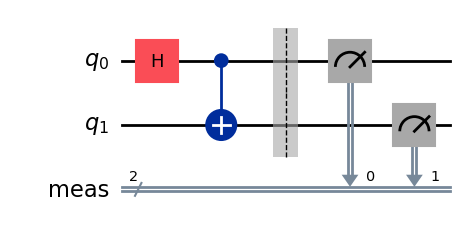

In [44]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicProvider

qc=QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.measure_all()

backend = BasicProvider().get_backend("basic_simulator")
tqc = transpile(qc, backend)
job = backend.run(tqc, shots=1000)
counts = job.result().get_counts()
print(counts)

qc.draw('mpl', style='iqp')

- RISULTATO:
    1. Esempio concettuale di output: `Statevector([0.70710678+0.j, 0.+0.j, 0.+0.j, 0.70710678+0.j], dims=(2, 2))`
        - sono le quattro ampiezze di probabilità per gli stati |00⟩, |01⟩, |10⟩, |11⟩ (2 qubit → 4 ampiezze)
        - il valore 0.7071 corrisponde circa a 1/√2: |00⟩ e |11⟩ hanno la stessa ampiezza, quindi probabilità 1/2 ciascuno
        - le ampiezze di |01⟩ e |10⟩ sono zero: i due qubit danno sempre lo stesso esito, lo stato non è solo sovrapposto ma entangled
        - è lo stato di Bell Φ⁺ = (|00⟩ + |11⟩)/√2, ottenuto applicando H al qubit 0 e poi CX(0, 1) a |00⟩
    2. Esempio concettuale di output: `Operator([[0.7071, 0.7071, 0, 0], [0, 0, 0.7071, -0.7071], [0, 0, 0.7071, 0.7071], [0.7071, -0.7071, 0, 0]], input_dims=(2, 2), output_dims=(2, 2))`
        - l'output è una matrice quadrata 4x4 di numeri complessi (una riga e una colonna per ogni stato di base)
        - è la matrice unitaria dell'intero circuito, cioè il prodotto CX · (I ⊗ H)
        - ogni colonna è lo stato in uscita per uno stato di base in ingresso, e le quattro colonne sono i quattro stati di Bell:
            - prima colonna, ingresso |00⟩: (|00⟩ + |11⟩)/√2 = Φ⁺
            - seconda colonna, ingresso |01⟩: (|00⟩ − |11⟩)/√2 = Φ⁻
            - terza colonna, ingresso |10⟩: (|01⟩ + |10⟩)/√2 = Ψ⁺
            - quarta colonna, ingresso |11⟩: (|10⟩ − |01⟩)/√2 = Ψ⁻ a meno di un segno globale
        - la prima colonna coincide con lo Statevector del punto 1, perché il circuito parte da |00⟩

- IMPORTANTE: convenzione Qiskit -> nell'etichetta |q1 q0⟩ il qubit 0 è la cifra più a destra, quindi |01⟩ significa qubit 0 = 1 e qubit 1 = 0

In [47]:
from qiskit.quantum_info import Statevector, Operator

qc=QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

statevector = Statevector(qc)
print(statevector)

unitary = Operator(qc)
print(unitary)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))
Operator([[ 0.70710678+0.j,  0.70710678+0.j,  0.        +0.j,
            0.        +0.j],
          [ 0.        +0.j,  0.        +0.j,  0.70710678+0.j,
           -0.70710678+0.j],
          [ 0.        +0.j,  0.        +0.j,  0.70710678+0.j,
            0.70710678+0.j],
          [ 0.70710678+0.j, -0.70710678+0.j,  0.        +0.j,
            0.        +0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


# ESERCIZIO 3: Stato GHZ a n qubit, con n parametro di una funzione

- GHZ solitamente è un esempio di entanglement a 3 qbit, ma per fare partica con funzioni e cicli lo estendiamo a n qbit mantenendo la stessa logica
- RICORDA: CX = CNOT
- `to_dict()` serve per stampare solo i valori del vettore di stato diversi da 0
    - è utile quando aumenta il numero di qbit del circuito perchè lo spazio delle fasi è il prodotto tensoriale degli spazi 
        - 2 qbit -> $H^4$
        - 3 qbit -> $H^8$
- `num_qubits` quanti fili ha il circuito, fissato alla creazione con QuantumCircuit(n)
- `size()` numero totale di porte

In [56]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

def ghz_nq(n):
    qc = QuantumCircuit(n)
    qc.h(0)                    # sovrapposizione sul qubit 0
    for i in range(n - 1):
        qc.cx(i, i + 1)        # CX a catena: 0→1, 1→2, ...
    return qc

qc = ghz_nq(10)
print(qc)
print(Statevector(qc).to_dict()) 
print(qc.num_qubits, qc.size())

# qc.draw('mpl', style='iqp') 

     ┌───┐                                             
q_0: ┤ H ├──■──────────────────────────────────────────
     └───┘┌─┴─┐                                        
q_1: ─────┤ X ├──■─────────────────────────────────────
          └───┘┌─┴─┐                                   
q_2: ──────────┤ X ├──■────────────────────────────────
               └───┘┌─┴─┐                              
q_3: ───────────────┤ X ├──■───────────────────────────
                    └───┘┌─┴─┐                         
q_4: ────────────────────┤ X ├──■──────────────────────
                         └───┘┌─┴─┐                    
q_5: ─────────────────────────┤ X ├──■─────────────────
                              └───┘┌─┴─┐               
q_6: ──────────────────────────────┤ X ├──■────────────
                                   └───┘┌─┴─┐          
q_7: ───────────────────────────────────┤ X ├──■───────
                                        └───┘┌─┴─┐     
q_8: ────────────────────────────────────────┤ X

# ESERCIZIO 4 - Funzione che, dato n, restituisce un circuito con H su tutti i qubit

- ho usato lo stesso modo del libro "qiskit poket guide - Using the Operator Flow Primitive Operators Classes "
- PROBELMI: 
    - il tipo di ritorno è CircuitOp, quando l'esercizio richiedeva un QuantumCircuit
    - qiskit.opflow è stato rimosso in Qiskit 1.0

In [71]:
from qiskit.opflow import H
def h_nq(n):    
    return H^n

print(h_nq(5))
print(type(hgates))

     ┌───┐
q_0: ┤ H ├
     ├───┤
q_1: ┤ H ├
     ├───┤
q_2: ┤ H ├
     ├───┤
q_3: ┤ H ├
     ├───┤
q_4: ┤ H ├
     └───┘
<class 'qiskit.opflow.primitive_ops.circuit_op.CircuitOp'>


- versione non deprecata e con ciclo esplicito che dovrebbe aiutare poi quando userò Nagini
- si può usare anche forma compatta qc.h(range(n)) al posto del ciclo

In [ ]:
from qiskit import QuantumCircuit

def h_nq(n):
    qc = QuantumCircuit(n)
    for i in range(n):
        qc.h(i)      
    return qc

qc = h_nq(5)
print(qc)
print(qc.num_qubits, qc.size())  
#qc.draw('mpl', style='iqp')

     ┌───┐
q_0: ┤ H ├
     ├───┤
q_1: ┤ H ├
     ├───┤
q_2: ┤ H ├
     ├───┤
q_3: ┤ H ├
     ├───┤
q_4: ┤ H ├
     └───┘
5 5
